18146.06557723502 0.0
0.8486452309468394


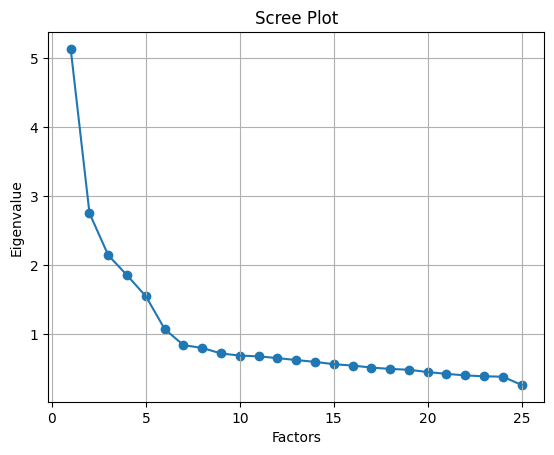

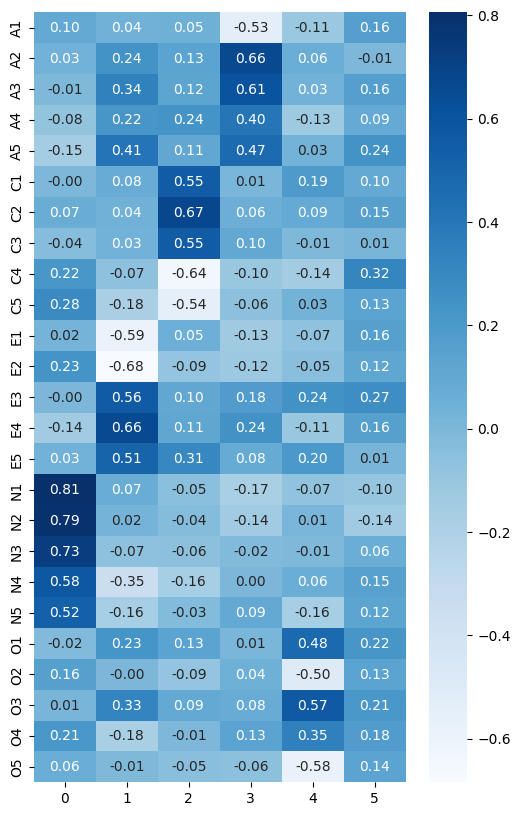

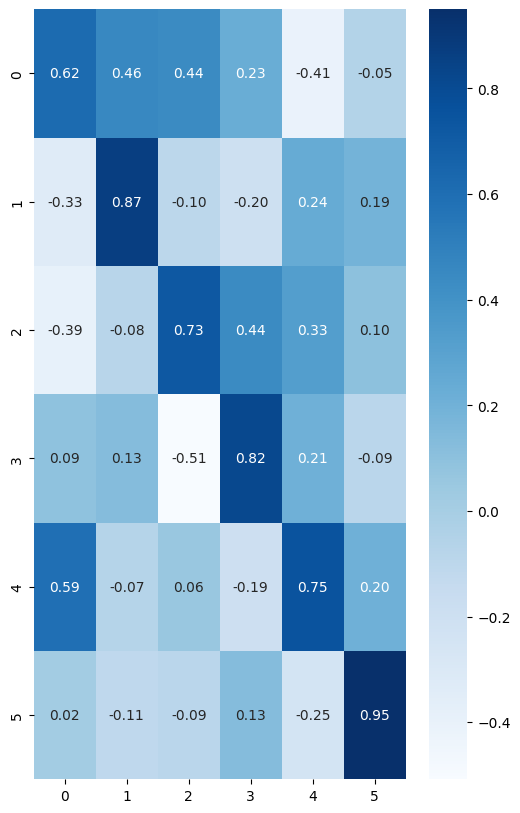

In [1]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bfi.csv', index_col=0)
# df.columns

df.drop(['gender', 'education', 'age'],axis=1,inplace=True)
df.dropna(inplace=True)
# df.info()

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value,p_value=calculate_bartlett_sphericity(df)
print(chi_square_value, p_value)

from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all,kmo_model=calculate_kmo(df)
print(kmo_model)

fa = FactorAnalyzer(n_factors=25,rotation=None)
fa.fit(df)
#Eigen값 체크 
ev, v = fa.get_eigenvalues()
plt.scatter(range(1,df.shape[1]+1),ev)
plt.plot(range(1,df.shape[1]+1),ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

fa = FactorAnalyzer(n_factors=6, rotation="varimax") #ml : 최대우도 방법
fa.fit(df)
efa_result= pd.DataFrame(fa.loadings_, index=df.columns)

plt.figure(figsize=(6,10))
sns.heatmap(efa_result, cmap="Blues", annot=True, fmt='.2f')
plt.show()

efa_result= pd.DataFrame(fa.rotation_matrix_)

plt.figure(figsize=(6,10))
sns.heatmap(efa_result, cmap="Blues", annot=True, fmt='.2f')
plt.show()